## # Iterative Methods for Linear Systems

This notebook implements the Jacobi and Gauss-Seidel methods for solving
linear systems and compares their convergence behavior on different
classes of matrices.

## Objectives
- implement the Jacobi method
- implement the Gauss-Seidel method
- analyze matrix properties relevant for convergence
- compare the residual decay of both methods

Matrix analysis
A1: symmetric = False, strictly diagonally dominant = True
    min eigenvalue = -7.397e+02, max eigenvalue = 7.531e+02
A2: symmetric = True, strictly diagonally dominant = False
    min eigenvalue = 8.898e+02, max eigenvalue = 2.249e+03



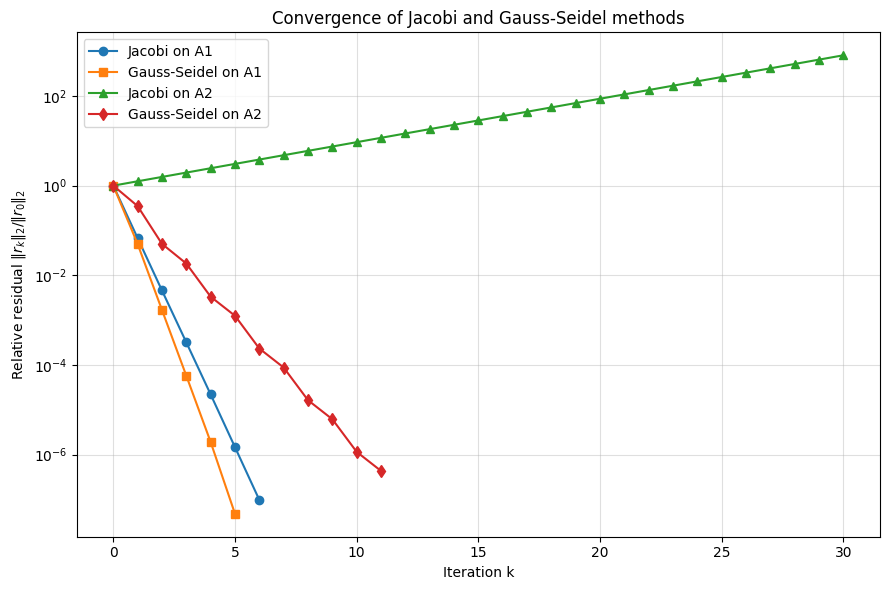

Summary
A1 is strictly diagonally dominant: True
A2 is symmetric positive definite: True
In many cases, Gauss-Seidel converges faster than Jacobi.
Plot saved to: iterative_methods_convergence.png


In [1]:
# ================================================
# Iterative Methods for Linear Systems
# Jacobi Method, Gauss-Seidel Method, and Convergence Analysis
# ================================================

import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)


# ------------------------------------------------
# Matrix property checks
# ------------------------------------------------
def is_symmetric(A, atol=1e-12):
    """
    Check whether a matrix is symmetric.
    """
    return np.allclose(A, A.T, atol=atol)


def is_strictly_diagonally_dominant(A):
    """
    Check whether a matrix is strictly diagonally dominant row-wise.
    """
    abs_A = np.abs(A)
    diagonal = np.diag(abs_A)
    off_diagonal_sum = np.sum(abs_A, axis=1) - diagonal
    return np.all(diagonal > off_diagonal_sum)


# ------------------------------------------------
# Iterative solvers
# ------------------------------------------------
def jacobi_method(A, b, x0, tol=1e-8, max_iter=100):
    """
    Solve Ax = b using the Jacobi method.
    """
    A = np.array(A, dtype=float, copy=False)
    b = np.array(b, dtype=float, copy=False)
    x = np.array(x0, dtype=float, copy=True)

    n = A.shape[0]
    if A.ndim != 2 or A.shape[1] != n:
        raise ValueError("A must be a square matrix.")
    if b.shape[0] != n or x.shape[0] != n:
        raise ValueError("Dimensions of A, b, and x0 do not match.")

    diagonal = np.diag(A)
    if np.any(np.isclose(diagonal, 0.0)):
        raise ZeroDivisionError("Jacobi method requires nonzero diagonal entries.")

    remainder = A - np.diagflat(diagonal)

    iterates = [x.copy()]
    r0 = b - A @ x
    norm_r0 = np.linalg.norm(r0, 2)
    norm_r0 = 1.0 if norm_r0 == 0 else norm_r0
    relative_residuals = [np.linalg.norm(r0, 2) / norm_r0]

    for _ in range(max_iter):
        x = (b - remainder @ x) / diagonal
        iterates.append(x.copy())

        rk = b - A @ x
        rel_res = np.linalg.norm(rk, 2) / norm_r0
        relative_residuals.append(rel_res)

        if rel_res <= tol:
            break

    return np.column_stack(iterates), np.array(relative_residuals)


def gauss_seidel_method(A, b, x0, tol=1e-8, max_iter=100):
    """
    Solve Ax = b using the Gauss-Seidel method.
    """
    A = np.array(A, dtype=float, copy=False)
    b = np.array(b, dtype=float, copy=False)
    x = np.array(x0, dtype=float, copy=True)

    n = A.shape[0]
    if A.ndim != 2 or A.shape[1] != n:
        raise ValueError("A must be a square matrix.")
    if b.shape[0] != n or x.shape[0] != n:
        raise ValueError("Dimensions of A, b, and x0 do not match.")

    if np.any(np.isclose(np.diag(A), 0.0)):
        raise ZeroDivisionError("Gauss-Seidel method requires nonzero diagonal entries.")

    iterates = [x.copy()]
    r0 = b - A @ x
    norm_r0 = np.linalg.norm(r0, 2)
    norm_r0 = 1.0 if norm_r0 == 0 else norm_r0
    relative_residuals = [np.linalg.norm(r0, 2) / norm_r0]

    for _ in range(max_iter):
        x_new = x.copy()

        for i in range(n):
            sigma_1 = np.dot(A[i, :i], x_new[:i])
            sigma_2 = np.dot(A[i, i + 1:], x[i + 1:])
            x_new[i] = (b[i] - sigma_1 - sigma_2) / A[i, i]

        x = x_new
        iterates.append(x.copy())

        rk = b - A @ x
        rel_res = np.linalg.norm(rk, 2) / norm_r0
        relative_residuals.append(rel_res)

        if rel_res <= tol:
            break

    return np.column_stack(iterates), np.array(relative_residuals)


# ------------------------------------------------
# Test matrix generators
# ------------------------------------------------
def generate_diagonally_dominant_matrix(n):
    """
    Generate a random strictly diagonally dominant matrix.
    """
    if n > 1000:
        raise ValueError("n should not exceed 1000 for this experiment.")

    A = RNG.uniform(-5.0, 5.0, size=(n, n))
    A = A - np.diag(np.diag(A))

    signs = (-1.0) ** np.arange(1, n + 1)
    diagonal_values = signs * (1.1 * np.sum(np.abs(A), axis=1))
    A = A + np.diag(diagonal_values)

    return A


def generate_spd_matrix(n):
    """
    Generate a random symmetric positive definite matrix.
    """
    if n > 1000:
        raise ValueError("n should not exceed 1000 for this experiment.")

    while True:
        M = RNG.integers(1, 10, size=(n, n))
        A = np.tril(M) + np.tril(M, k=-1).T
        A = A - np.diag(np.diag(A))
        A = A + np.diag(0.8 * np.sum(A, axis=1))

        eigenvalues = np.linalg.eigvalsh(A)
        if np.min(eigenvalues) > 0:
            return A


# ------------------------------------------------
# Matrix analysis
# ------------------------------------------------
def analyze_test_matrices(n):
    """
    Generate two matrices and analyze their key properties.
    """
    A1 = generate_diagonally_dominant_matrix(n)
    A2 = generate_spd_matrix(n)

    sym_1 = is_symmetric(A1)
    sym_2 = is_symmetric(A2)

    eigenvalues_1 = np.linalg.eigvalsh(A1) if sym_1 else np.linalg.eigvals(A1)
    eigenvalues_2 = np.linalg.eigvalsh(A2) if sym_2 else np.linalg.eigvals(A2)

    results = {
        "A1": A1,
        "A2": A2,
        "symmetry_A1": sym_1,
        "symmetry_A2": sym_2,
        "sdd_A1": is_strictly_diagonally_dominant(A1),
        "sdd_A2": is_strictly_diagonally_dominant(A2),
        "lambda_min_A1": np.min(np.real(eigenvalues_1)),
        "lambda_max_A1": np.max(np.real(eigenvalues_1)),
        "lambda_min_A2": np.min(np.real(eigenvalues_2)),
        "lambda_max_A2": np.max(np.real(eigenvalues_2)),
    }

    print("Matrix analysis")
    print(f"A1: symmetric = {results['symmetry_A1']}, strictly diagonally dominant = {results['sdd_A1']}")
    print(f"    min eigenvalue = {results['lambda_min_A1']:.3e}, max eigenvalue = {results['lambda_max_A1']:.3e}")
    print(f"A2: symmetric = {results['symmetry_A2']}, strictly diagonally dominant = {results['sdd_A2']}")
    print(f"    min eigenvalue = {results['lambda_min_A2']:.3e}, max eigenvalue = {results['lambda_max_A2']:.3e}")
    print()

    return results


# ------------------------------------------------
# Convergence comparison
# ------------------------------------------------
def compare_convergence(n=200, tol=1e-6, max_iter=30):
    """
    Compare Jacobi and Gauss-Seidel convergence on two test matrices.
    """
    A1 = generate_diagonally_dominant_matrix(n)
    A2 = generate_spd_matrix(n)
    b = np.ones(n)
    x0 = np.zeros(n)

    _, res_jacobi_A1 = jacobi_method(A1, b, x0, tol=tol, max_iter=max_iter)
    _, res_gs_A1 = gauss_seidel_method(A1, b, x0, tol=tol, max_iter=max_iter)

    _, res_jacobi_A2 = jacobi_method(A2, b, x0, tol=tol, max_iter=max_iter)
    _, res_gs_A2 = gauss_seidel_method(A2, b, x0, tol=tol, max_iter=max_iter)

    results = {
        "jacobi_A1": res_jacobi_A1,
        "gauss_seidel_A1": res_gs_A1,
        "jacobi_A2": res_jacobi_A2,
        "gauss_seidel_A2": res_gs_A2,
    }

    plt.figure(figsize=(9, 6))
    plt.semilogy(np.arange(len(res_jacobi_A1)), res_jacobi_A1, "o-", label="Jacobi on A1")
    plt.semilogy(np.arange(len(res_gs_A1)), res_gs_A1, "s-", label="Gauss-Seidel on A1")
    plt.semilogy(np.arange(len(res_jacobi_A2)), res_jacobi_A2, "^-", label="Jacobi on A2")
    plt.semilogy(np.arange(len(res_gs_A2)), res_gs_A2, "d-", label="Gauss-Seidel on A2")

    plt.xlabel("Iteration k")
    plt.ylabel(r"Relative residual $\|r_k\|_2 / \|r_0\|_2$")
    plt.title("Convergence of Jacobi and Gauss-Seidel methods")
    plt.grid(True, which="both", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results


# ------------------------------------------------
# Optional: save convergence plot
# ------------------------------------------------
def save_convergence_plot(results, filename="iterative_methods_convergence.png"):
    """
    Save the convergence comparison plot to an image file.
    """
    plt.figure(figsize=(9, 6))
    plt.semilogy(np.arange(len(results["jacobi_A1"])), results["jacobi_A1"], "o-", label="Jacobi on A1")
    plt.semilogy(np.arange(len(results["gauss_seidel_A1"])), results["gauss_seidel_A1"], "s-", label="Gauss-Seidel on A1")
    plt.semilogy(np.arange(len(results["jacobi_A2"])), results["jacobi_A2"], "^-", label="Jacobi on A2")
    plt.semilogy(np.arange(len(results["gauss_seidel_A2"])), results["gauss_seidel_A2"], "d-", label="Gauss-Seidel on A2")

    plt.xlabel("Iteration k")
    plt.ylabel(r"Relative residual $\|r_k\|_2 / \|r_0\|_2$")
    plt.title("Convergence of Jacobi and Gauss-Seidel methods")
    plt.grid(True, which="both", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Plot saved to: {filename}")


# ------------------------------------------------
# Example execution in notebook
# ------------------------------------------------
matrix_results = analyze_test_matrices(n=250)
convergence_results = compare_convergence(n=250, tol=1e-6, max_iter=30)

print("Summary")
print(f"A1 is strictly diagonally dominant: {matrix_results['sdd_A1']}")
print(f"A2 is symmetric positive definite: {matrix_results['symmetry_A2'] and matrix_results['lambda_min_A2'] > 0}")
print("In many cases, Gauss-Seidel converges faster than Jacobi.")

# Save PNG for later download
save_convergence_plot(convergence_results, filename="iterative_methods_convergence.png")

## Conclusion

The experiments illustrate that convergence strongly depends on the
matrix structure. For strictly diagonally dominant systems, both Jacobi
and Gauss-Seidel are expected to converge. In practice, Gauss-Seidel
often converges faster because it immediately uses newly updated values
within each iteration. For symmetric positive definite matrices,
the convergence behavior can also be favorable, although the speed may
still differ significantly between methods.